# Segmentation client RFM – GlobalShop Direct

**Mission** : NexaData Consulting – Segmentation marketing
**Binôme** : Suz & Laurie

## Contexte
La direction marketing de la plateforme e-commerce **GlobalShop Direct** souhaite mieux connaître ses clients afin de personnaliser ses actions commerciales. À partir de l'historique des transactions (online_retail.csv, déc. 2010 → déc. 2011), nous devons regrouper les clients en segments homogènes selon leur comportement d'achat.

## Objectifs
1. Nettoyer les transactions brutes (annulations, valeurs manquantes, prix et quantités négatifs).
2. Construire la matrice **RFM** (Récence, Fréquence, Montant) pour chaque client.
3. Réduire l'asymétrie (log) et standardiser les variables.
4. Segmenter les clients avec **K-means** et le **clustering hiérarchique**, et justifier le nombre de clusters K (coude, silhouette).
5. Visualiser les segments en 2D grâce à la **PCA**.
6. Donner une identité métier à chaque segment (**personas**) et proposer des **actions marketing**.

## Plan du notebook
1. Diagnostic de la qualité des données
2. Nettoyage
3. Construction de la matrice RFM
4. Traitement de l'asymétrie et standardisation
5. Choix du nombre de clusters K
6. Clustering
7. Réduction de dimension (PCA)
8. Profilage des segments et personas
9. KPI clés
10. Sauvegarde du modèle
11. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel(r"C:\Users\utilisateur\Downloads\salma s doc\machine learning\Machine-Learning-Mise-en-pratique\data\Online_Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.to_csv("online_retail.csv", index=False)

In [5]:
print(df.shape)
df.info()

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 1. Diagnostic de la qualité des données

In [6]:
print("Valeurs manquantes :")
print(df.isnull().sum())
print("\nDoublons :", df.duplicated().sum())
print("Factures annulées (InvoiceNo commence par 'C') :", df["InvoiceNo"].astype(str).str.startswith("C").sum())
print("Quantités <= 0 :", (df["Quantity"] <= 0).sum())
print("Prix <= 0 :", (df["UnitPrice"] <= 0).sum())
print("Période :", df["InvoiceDate"].min(), "→", df["InvoiceDate"].max())

Valeurs manquantes :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Doublons : 5268
Factures annulées (InvoiceNo commence par 'C') : 9288
Quantités <= 0 : 10624
Prix <= 0 : 2517
Période : 2010-12-01 08:26:00 → 2011-12-09 12:50:00


**Constat** : 25 % des transactions n'ont pas de CustomerID (inutilisables pour une analyse par client). On trouve aussi des doublons, des factures annulées (« C ») avec des quantités négatives, et des prix nuls ou négatifs. Ces lignes doivent être supprimées avant de construire la RFM.

## 2. Nettoyage des données
Chaque règle est appliquée l'une après l'autre ; on affiche le nombre de lignes supprimées pour assurer la traçabilité.

### 2.1 Copie de travail

In [7]:
# Copie de travail pour conserver les données brutes intactes
df_clean = df.copy()
n_initial = len(df_clean)


def etape(df_avant_len, df_apres, libelle):
    """Affiche le nombre de lignes supprimées par une règle de nettoyage."""
    print(f"{libelle:<30} : -{df_avant_len - len(df_apres):>7,} lignes "
          f"→ {len(df_apres):,} restantes")


print("Lignes au départ :", n_initial)

Lignes au départ : 541909


### 2.2 Suppression des transactions sans client
Sans `CustomerID`, impossible de rattacher l'achat à un client : ces lignes sont inexploitables pour la RFM.

In [8]:
n = len(df_clean)
df_clean = df_clean.dropna(subset=["CustomerID"])
etape(n, df_clean, "CustomerID manquant")

CustomerID manquant            : -135,080 lignes → 406,829 restantes


### 2.3 Suppression des doublons

In [9]:
n = len(df_clean)
df_clean = df_clean.drop_duplicates()
etape(n, df_clean, "Doublons")

Doublons                       : -  5,225 lignes → 401,604 restantes


### 2.4 Suppression des factures annulées
Les factures dont le numéro commence par « C » sont des annulations ou des retours : ce ne sont pas des achats réels.

In [10]:
n = len(df_clean)
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
etape(n, df_clean, "Factures annulées")

Factures annulées              : -  8,872 lignes → 392,732 restantes


### 2.5 Suppression des quantités et prix nuls ou négatifs

In [11]:
n = len(df_clean)
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]
etape(n, df_clean, "Quantité ou prix <= 0")

Quantité ou prix <= 0          : -     40 lignes → 392,692 restantes


### 2.6 Suppression des codes qui ne sont pas des produits
Frais de port (POST, DOT), ajustements manuels (M), frais bancaires, etc. : ce ne sont pas de vrais achats.

In [12]:
codes_non_produits = ["POST", "M", "C2", "DOT", "BANK CHARGES",
                      "PADS", "AMAZONFEE", "CRUK", "D", "S", "B"]
n = len(df_clean)
df_clean = df_clean[~df_clean["StockCode"].astype(str).isin(codes_non_produits)]
etape(n, df_clean, "Codes non-produits")

Codes non-produits             : -  1,542 lignes → 391,150 restantes


### 2.7 Suppression des commandes géantes annulées
Deux commandes de 80 995 et 74 215 unités ont été annulées le jour même : ce sont des valeurs aberrantes qui fausseraient le Montant.

In [13]:
n = len(df_clean)
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).isin(["581483", "541431"])]
etape(n, df_clean, "Commandes géantes annulées")

Commandes géantes annulées     : -      2 lignes → 391,148 restantes


### 2.8 Bilan du nettoyage

In [14]:
total_supprime = n_initial - len(df_clean)
print(f"Total supprimé : {total_supprime:,} lignes ({total_supprime / n_initial:.1%})")
print(f"Lignes restantes : {len(df_clean):,}")
print(f"Clients uniques : {df_clean['CustomerID'].nunique():,}")

Total supprimé : 150,761 lignes (27.8%)
Lignes restantes : 391,148
Clients uniques : 4,333


**Bilan** : après nettoyage, il reste 391 148 transactions (≈ 72 % des données) pour 4 333 clients. Les données sont prêtes pour construire la matrice RFM.

## 3. Construction de la matrice RFM
- **Récence (R)** : nombre de jours depuis le dernier achat du client
- **Fréquence (F)** : nombre de commandes distinctes
- **Montant (M)** : somme totale dépensée

### 3.1 Calcul du montant de chaque ligne

In [15]:
# Montant d'une ligne = quantité × prix unitaire
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean[["Quantity", "UnitPrice", "TotalPrice"]].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### 3.2 Date de référence
On se place au lendemain de la dernière transaction, comme si l'analyse était faite ce jour-là.

In [16]:
date_reference = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Date de référence :", date_reference)

Date de référence : 2011-12-10 12:50:00


### 3.3 Agrégation par client

In [17]:
rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (date_reference - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
)

print("Dimensions :", rfm.shape)
rfm.head()

Dimensions : (4333, 3)


,Recency,Frequency,Monetary
CustomerID,,,
12347.0,2,7,4310.00
12348.0,75,4,1437.24
12349.0,19,1,1457.55
12350.0,310,1,294.40
12352.0,36,7,1385.74


### 3.4 Vérification de la matrice RFM

In [18]:
print("Valeurs manquantes :", rfm.isnull().sum().sum())
print("Clients en double :", rfm.index.duplicated().sum())
rfm.describe().round(1)

Valeurs manquantes : 0
Clients en double : 0


,Recency,Frequency,Monetary
count,4333.0,4333.0,4333.0
mean,92.7,4.2,1959.7
std,100.1,7.6,8461.2
min,1.0,1.0,2.9
25%,18.0,1.0,304.0
50%,51.0,2.0,661.3
75%,143.0,5.0,1628.6
max,374.0,206.0,279138.0


**Constat** : 4 333 clients, aucune valeur manquante ni doublon. Les écarts sont énormes : la Fréquence va de 1 à 206 et le Montant de 3 à 279 138 £, alors que la médiane n'est que de 2 commandes et 661 £. Les distributions sont très asymétriques → il faudra les transformer (log) avant le clustering.

## 4. Traitement de l'asymétrie et standardisation

### 4.1 Visualisation des distributions brutes

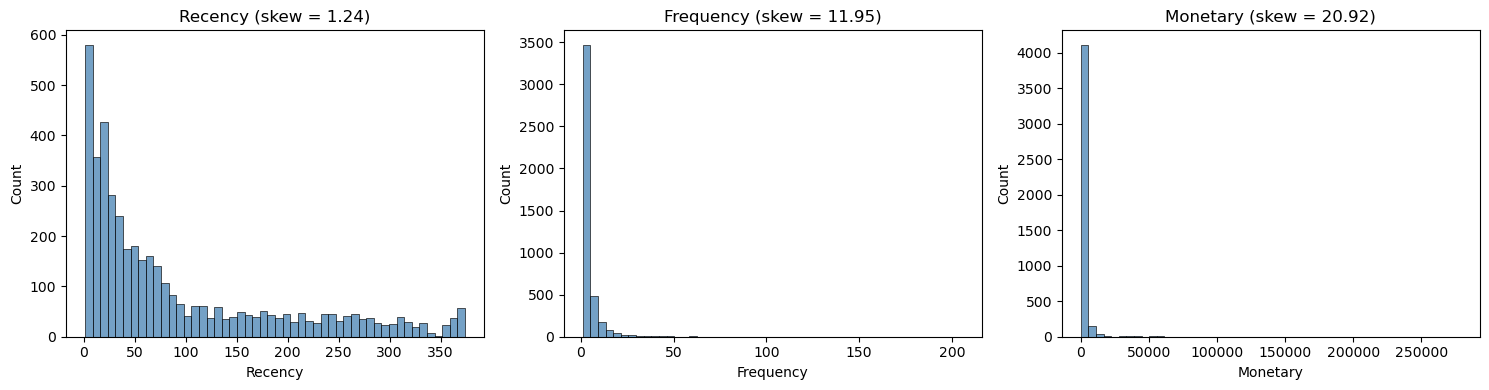

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], bins=50, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col} (skew = {rfm[col].skew():.2f})")
plt.tight_layout()
plt.show()

**Constat** : les 3 distributions sont très asymétriques à droite, surtout la Fréquence (skew ≈ 12) et le Montant (skew ≈ 21) : quelques très gros clients écrasent tous les autres. K-means, basé sur les distances, serait dominé par ces valeurs extrêmes.

### 4.2 Transformation logarithmique (log1p)
`np.log1p(x)` calcule log(1 + x) : il « compresse » les grandes valeurs et réduit l'asymétrie. Le +1 évite l'erreur log(0).

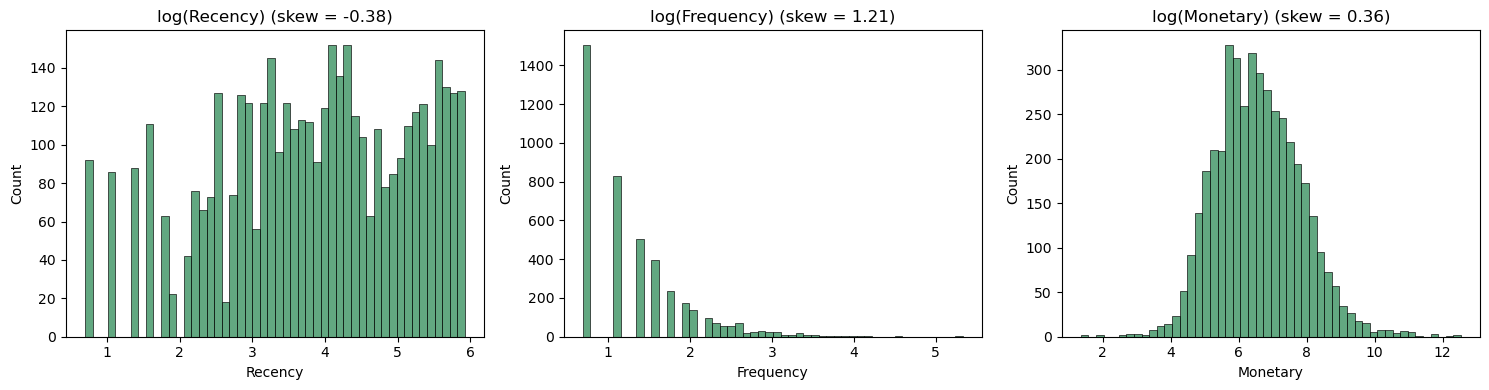

In [20]:
# Application du log sur les 3 variables RFM
rfm_log = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])

# Visualisation après transformation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm_log[col], bins=50, ax=axes[i], color="seagreen")
    axes[i].set_title(f"log({col}) (skew = {rfm_log[col].skew():.2f})")
plt.tight_layout()
plt.show()

**Constat** : après log1p, l'asymétrie chute fortement (Monetary : 20,9 → 0,36 ; Frequency : 11,9 → 1,2). Les distributions sont bien plus équilibrées : les gros clients n'écraseront plus les autres dans le calcul des distances.

### 4.3 Standardisation
Les 3 variables n'ont pas la même échelle (jours, nombre de commandes, £). On les ramène à une moyenne de 0 et un écart-type de 1 pour qu'elles pèsent autant dans K-means.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Remise en DataFrame pour garder les noms de colonnes et les CustomerID
rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm_log.columns, index=rfm_log.index)

rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,4333.00,4333.00,4333.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.95,-4.16
25%,-0.66,-0.95,-0.68
50%,0.09,-0.36,-0.06
75%,0.85,0.66,0.66
max,1.56,5.85,4.76


**Constat** : les 3 variables ont désormais une moyenne de 0 et un écart-type de 1. Les données sont prêtes pour le clustering.

## 5. Choix du nombre de clusters K
On combine deux méthodes : la méthode du coude (inertie) et le coefficient de silhouette.

### 5.1 Méthode du coude et coefficient de silhouette

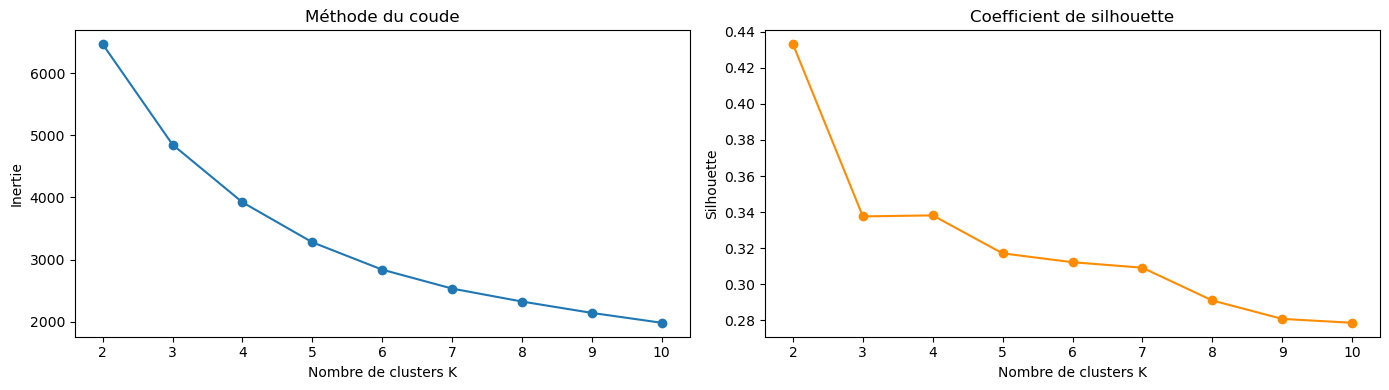

,K,Inertie,Silhouette
0,2,6467.152,0.433
1,3,4849.929,0.338
2,4,3921.947,0.338
3,5,3278.022,0.317
4,6,2837.623,0.312
5,7,2533.050,0.309
6,8,2324.300,0.291
7,9,2141.356,0.281
8,10,1982.222,0.279


In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
inerties = []
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inerties.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

# Affichage des deux courbes côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inerties, marker="o")
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_ylabel("Inertie")

axes[1].plot(K_range, silhouettes, marker="o", color="darkorange")
axes[1].set_title("Coefficient de silhouette")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

# Tableau récapitulatif
pd.DataFrame({"K": K_range, "Inertie": inerties, "Silhouette": silhouettes}).round(3)

**Choix de K = 4** :
- La **silhouette** est maximale pour K = 2, mais 2 segments sont trop grossiers pour du marketing (« bons » vs « mauvais » clients).
- Pour K = 3 et K = 4, la silhouette est **identique (0,338)**, puis elle baisse à partir de K = 5.
- Le **coude** de l'inertie se situe autour de K = 4 : au-delà, le gain devient faible.

→ **K = 4** est le meilleur compromis entre qualité statistique et exploitabilité métier (4 personas actionnables).

## 6. Clustering
On applique K-means avec K = 4, puis on compare avec le clustering hiérarchique (Ward) pour valider le choix du modèle.

### 6.1 K-means avec K = 4

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Nombre de clients par cluster :")
print(rfm["Cluster"].value_counts().sort_index())
rfm.head()

Nombre de clients par cluster :
Cluster
0     685
1    1637
2     834
3    1177
Name: count, dtype: int64


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,2,7,4310.00,0
12348.0,75,4,1437.24,3
12349.0,19,1,1457.55,2
12350.0,310,1,294.40,1
12352.0,36,7,1385.74,3


### 6.2 Comparaison avec le clustering hiérarchique (Ward)

In [24]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_hc = hc.fit_predict(rfm_scaled)

print("Silhouette K-means :", round(silhouette_score(rfm_scaled, rfm["Cluster"]), 3))
print("Silhouette Hiérarchique :", round(silhouette_score(rfm_scaled, labels_hc), 3))

pd.crosstab(rfm["Cluster"], labels_hc, rownames=["K-means"], colnames=["Hiérarchique"])

Silhouette K-means : 0.338
Silhouette Hiérarchique : 0.264


Hiérarchique,0,1,2,3
K-means,,,,
0,34,651,0,0
1,211,0,994,432
2,260,2,0,572
3,895,248,7,27


**Choix du modèle : K-means**
- Silhouette nettement meilleure (0,338 vs 0,264) : clusters plus compacts et mieux séparés.
- Les deux méthodes s'accordent sur environ 72 % des clients (même structure globale).
- K-means peut **classer un nouveau client** avec `.predict()`, ce qui est indispensable pour l'outil de qualification du dashboard Streamlit. Le clustering hiérarchique ne le permet pas.

## 7. Réduction de dimension (PCA)
Objectif : projeter les clients en 2D pour visualiser la séparation des 4 clusters.

### 7.1 Variance expliquée

PC1 : 75.2%  (cumulée : 75.2%)
PC2 : 18.7%  (cumulée : 94.0%)
PC3 : 6.0%  (cumulée : 100.0%)


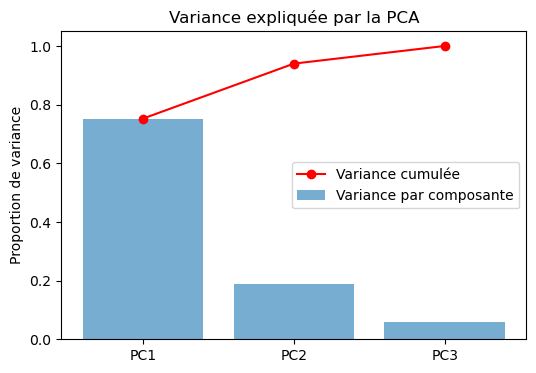

In [25]:
from sklearn.decomposition import PCA

# PCA complète (3 composantes) pour analyser la variance
pca_full = PCA(random_state=42)
pca_full.fit(rfm_scaled)

variance = pca_full.explained_variance_ratio_
variance_cumulee = variance.cumsum()

for i, (v, vc) in enumerate(zip(variance, variance_cumulee), start=1):
    print(f"PC{i} : {v:.1%}  (cumulée : {vc:.1%})")

plt.figure(figsize=(6, 4))
plt.bar(range(1, 4), variance, alpha=0.6, label="Variance par composante")
plt.plot(range(1, 4), variance_cumulee, marker="o", color="red", label="Variance cumulée")
plt.xticks([1, 2, 3], ["PC1", "PC2", "PC3"])
plt.ylabel("Proportion de variance")
plt.title("Variance expliquée par la PCA")
plt.legend()
plt.show()

**Constat** : les 2 premières composantes capturent **94 % de la variance**. La projection en 2D représente donc très fidèlement les données ; on ne perd que 6 % de l'information.

### 7.2 Interprétation des composantes

In [26]:
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

contributions = pd.DataFrame(
    pca.components_,
    columns=["Recency", "Frequency", "Monetary"],
    index=["PC1", "PC2"],
).round(2)
contributions

,Recency,Frequency,Monetary
PC1,-0.51,0.62,0.60
PC2,0.85,0.26,0.46


**Interprétation** :
- **PC1 = « valeur du client »** : elle augmente avec la Fréquence et le Montant, et diminue avec la Récence. À droite : les clients qui achètent souvent, beaucoup et récemment.
- **PC2 = « ancienneté du dernier achat »** : dominée par la Récence (0,85). En haut : les clients qui n'ont pas acheté depuis longtemps.

### 7.3 Projection 2D des clusters

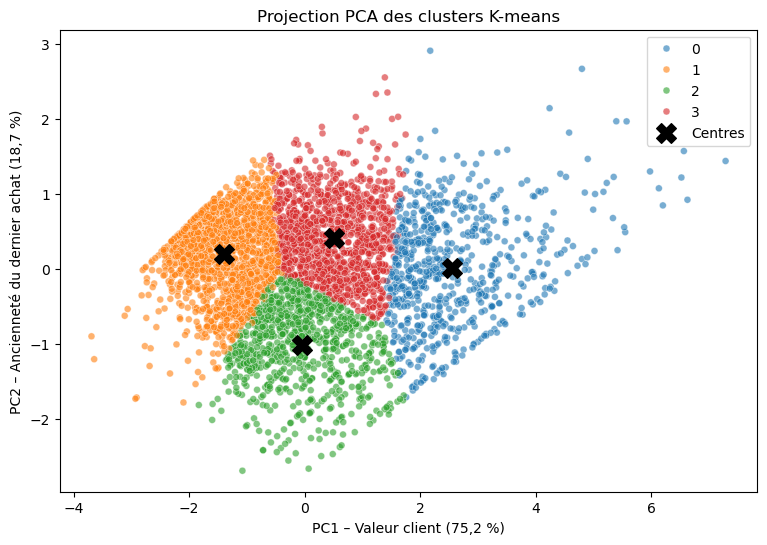

In [27]:
rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster",
                palette="tab10", alpha=0.6, s=25)

# Centres des clusters projetés en 2D
centres_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centres_pca[:, 0], centres_pca[:, 1], c="black", marker="X",
            s=200, label="Centres")

plt.title("Projection PCA des clusters K-means")
plt.xlabel("PC1 – Valeur client (75,2 %)")
plt.ylabel("PC2 – Ancienneté du dernier achat (18,7 %)")
plt.legend()
plt.show()

**Constat** : les 4 clusters sont bien séparés le long de l'axe PC1 (valeur client), avec un léger chevauchement aux frontières, normal pour des comportements d'achat continus. La projection confirme la cohérence de la segmentation K = 4.

## 8. Profilage des segments et personas marketing

### 8.1 Moyennes et médianes RFM par cluster
On regarde aussi la médiane, car la moyenne du Montant est tirée vers le haut par quelques très gros clients.

In [28]:
profil = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].agg(["mean", "median"]).round(1)
profil

Recency        Frequency        Monetary        
           mean median      mean median     mean  median
Cluster                                                 
0          11.8    8.0      14.0   10.0   7934.7  3719.1
1         182.8  177.0       1.3    1.0    349.9   298.4
2          18.3   17.0       2.1    2.0    533.0   459.2
3          67.2   52.0       4.2    4.0   1732.5  1353.7

### 8.2 Attribution d'un nom à chaque segment

In [29]:
# Correspondance numéro de cluster → persona (d'après le tableau 8.1)
noms_segments = {
    0: "Champions",
    1: "Clients perdus",
    2: "Nouveaux clients",
    3: "Clients fidèles",
}
rfm["Segment"] = rfm["Cluster"].map(noms_segments)
rfm["Segment"].value_counts()

Segment
Clients perdus      1637
Clients fidèles     1177
Nouveaux clients     834
Champions            685
Name: count, dtype: int64

### 8.3 Distribution de R, F et M par segment (boxplots)

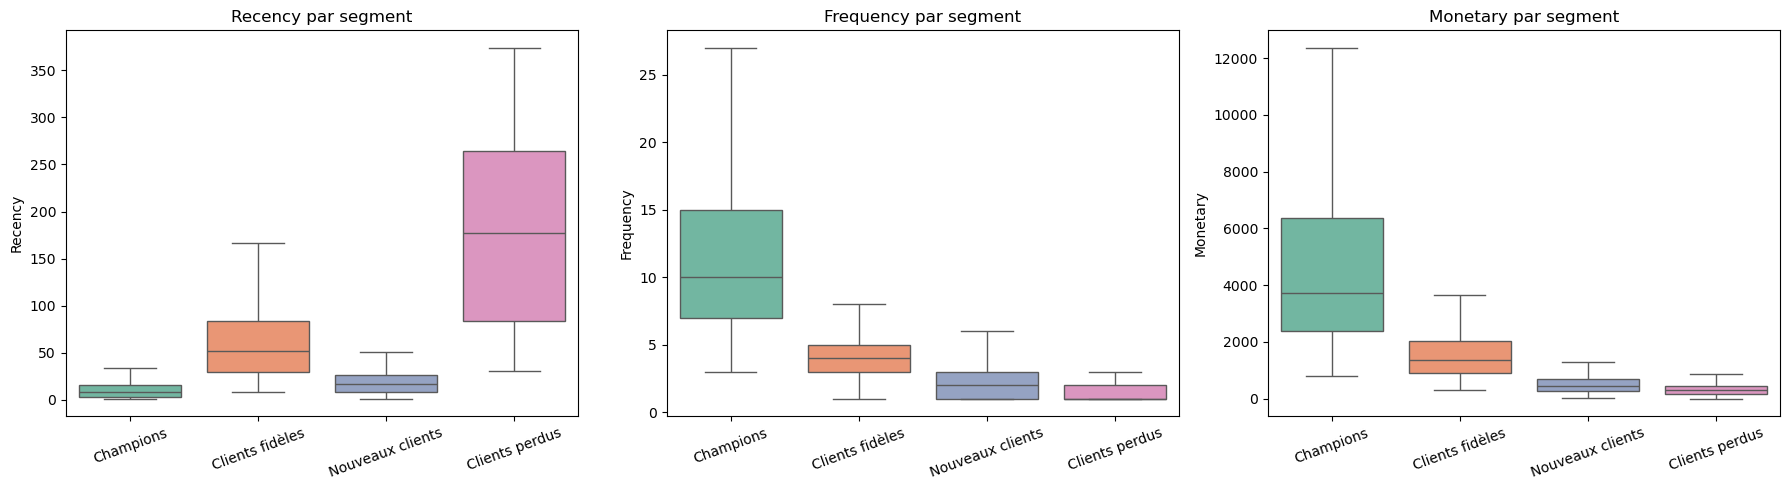

In [30]:
ordre = ["Champions", "Clients fidèles", "Nouveaux clients", "Clients perdus"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    sns.boxplot(data=rfm, x="Segment", y=col, order=ordre,
                palette="Set2", ax=axes[i], showfliers=False)
    axes[i].set_title(f"{col} par segment")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

**Constat** : les boxplots confirment des profils bien distincts. Les **Champions** ont une récence très faible et la fréquence et le montant les plus élevés. À l'opposé, les **Clients perdus** n'ont pas acheté depuis environ 6 mois et n'ont souvent passé qu'une seule commande. Les **Nouveaux clients** sont récents mais encore peu engagés, et les **Clients fidèles** se situent entre les deux.

### 8.4 Personas et recommandations marketing

| Segment | Profil type (médianes) | Poids | Recommandation marketing |
|---|---|---|---|
| 🏆 **Champions** | Dernier achat il y a ~8 j, ~10 commandes, ~3 700 £ | 16 % des clients → **64 % du CA** | Programme VIP, accès en avant-première aux nouveautés, remerciements personnalisés. **Objectif : les retenir.** |
| 💙 **Clients fidèles** | Dernier achat il y a ~52 j, ~4 commandes, ~1 350 £ | 27 % → 24 % du CA | Programme de fidélité à paliers, recommandations de produits complémentaires. **Objectif : les faire passer Champions.** |
| 🌱 **Nouveaux clients** | Dernier achat il y a ~17 j, 1-2 commandes, ~460 £ | 19 % → 5 % du CA | Mail de bienvenue, code promo sur la 2e commande, découverte du catalogue. **Objectif : déclencher le réachat.** |
| 💤 **Clients perdus** | Dernier achat il y a ~6 mois, 1 commande, ~300 £ | **38 %** → 7 % du CA | Campagne de réactivation « Vous nous manquez » avec remise, à faible coût. **Objectif : en récupérer une partie sans surinvestir.** |

**Priorités** : 1) protéger les Champions (64 % du CA), 2) faire monter les Fidèles, 3) convertir les Nouveaux, 4) réactiver les Perdus à moindre coût.

In [45]:
# Recommandation marketing associée à chaque segment
actions_marketing = {
    "Champions": "Programme VIP, avant-premières, remerciements personnalisés",
    "Clients fidèles": "Fidélité à paliers, recommandations de produits complémentaires",
    "Nouveaux clients": "Mail de bienvenue, code promo sur la 2e commande",
    "Clients perdus": "Campagne de réactivation avec remise, à faible coût",
}

rfm["Action"] = rfm["Segment"].map(actions_marketing)
rfm[["Recency", "Frequency", "Monetary", "Segment", "Action"]].head()

,Recency,Frequency,Monetary,Segment,Action
CustomerID,,,,,
12347.0,2,7,4310.00,Champions,"Programme VIP, avant-premières, remerciements ..."
12348.0,75,4,1437.24,Clients fidèles,"Fidélité à paliers, recommandations de produit..."
12349.0,19,1,1457.55,Nouveaux clients,"Mail de bienvenue, code promo sur la 2e commande"
12350.0,310,1,294.40,Clients perdus,"Campagne de réactivation avec remise, à faible..."
12352.0,36,7,1385.74,Clients fidèles,"Fidélité à paliers, recommandations de produit..."


## 9. KPI Clés

### 9.1 KPI Globaux

In [46]:
total_revenue   = df_clean["TotalPrice"].sum()
total_orders    = df_clean["InvoiceNo"].nunique()
total_clients   = df_clean["CustomerID"].nunique()
total_products  = df_clean["StockCode"].nunique()
nb_pays         = df_clean["Country"].nunique()
panier_moyen    = total_revenue / total_orders
ca_par_client  = total_revenue / total_clients
freq_moyenne    = total_orders / total_clients
duree_periode   = (df_clean["InvoiceDate"].max() - df_clean["InvoiceDate"].min()).days
ca_jour_moyen   = total_revenue / duree_periode

kpi_globaux = pd.DataFrame({
    "KPI": [
        "Chiffre d'affaires total (£)",
        "Nombre de commandes",
        "Nombre de clients uniques",
        "Nombre de produits distincts",
        "Nombre de pays",
        "Panier moyen (£)",
        "CA moyen par client (£)",
        "Fréquence d'achat moyenne",
        "Durée de la période (jours)",
        "CA moyen par jour (£)"
    ],
    "Valeur": [
        f"{total_revenue:,.0f}",
        f"{total_orders:,}",
        f"{total_clients:,}",
        f"{total_products:,}",
        nb_pays,
        f"{panier_moyen:,.2f}",
        f"{ca_par_client:,.2f}",
        f"{freq_moyenne:.2f}",
        duree_periode,
        f"{ca_jour_moyen:,.0f}"
    ]
})
kpi_globaux

,KPI,Valeur
0,Chiffre d'affaires total (£),"8,491,574"
1,Nombre de commandes,"18,400"
2,Nombre de clients uniques,"4,333"
3,Nombre de produits distincts,"3,658"
4,Nombre de pays,37
5,Panier moyen (£),461.50
6,CA moyen par client (£),"1,959.74"
7,Fréquence d'achat moyenne,4.25
8,Durée de la période (jours),373
9,CA moyen par jour (£),"22,766"


### 9.2 KPI de concentration loi de Pareto

 26.8% des clients (1163) génèrent 80% du CA
 21.9% des produits (802) génèrent 80% du CA
 1 pays sur 37 génèrent 80% du CA


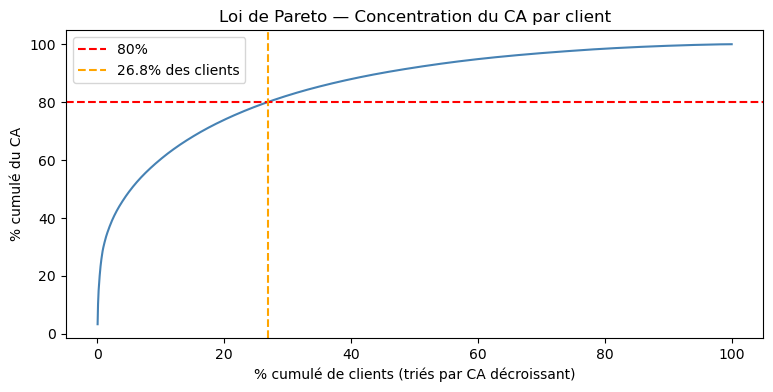

In [47]:
# --- Pareto clients ---
ca_par_client_sorted = rfm["Monetary"].sort_values(ascending=False)
cum_ca = ca_par_client_sorted.cumsum() / ca_par_client_sorted.sum()
n_80 = (cum_ca <= 0.80).sum() + 1
pct_clients_80 = n_80 / len(rfm) * 100

# --- Pareto produits ---
ca_par_produit = df_clean.groupby("StockCode")["TotalPrice"].sum().sort_values(ascending=False)
cum_prod = ca_par_produit.cumsum() / ca_par_produit.sum()
n_prod_80 = (cum_prod <= 0.80).sum() + 1
pct_prod_80 = n_prod_80 / len(ca_par_produit) * 100

# --- Pareto pays ---
ca_par_pays = df_clean.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
cum_pays = ca_par_pays.cumsum() / ca_par_pays.sum()
n_pays_80 = (cum_pays <= 0.80).sum() + 1

print(f" {pct_clients_80:.1f}% des clients ({n_80}) génèrent 80% du CA")
print(f" {pct_prod_80:.1f}% des produits ({n_prod_80}) génèrent 80% du CA")
print(f" {n_pays_80} pays sur {nb_pays} génèrent 80% du CA")

# Visualisation Pareto clients
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(cum_ca) + 1) / len(cum_ca) * 100,
        cum_ca.values * 100, color="steelblue")
ax.axhline(80, color="red", linestyle="--", label="80%")
ax.axvline(pct_clients_80, color="orange", linestyle="--",
           label=f"{pct_clients_80:.1f}% des clients")
ax.set_xlabel("% cumulé de clients (triés par CA décroissant)")
ax.set_ylabel("% cumulé du CA")
ax.set_title("Loi de Pareto — Concentration du CA par client")
ax.legend()
plt.show()

### 9.3 KPI par segment

In [48]:
kpi_segments = rfm.groupby("Segment").agg(
    Nb_clients       = ("Monetary", "count"),
    Recency_moy      = ("Recency", "mean"),
    Frequency_moy    = ("Frequency", "mean"),
    Monetary_moy     = ("Monetary", "mean"),
    Monetary_median  = ("Monetary", "median"),
    CA_total         = ("Monetary", "sum"),
).round(1)

kpi_segments["Pct_clients"] = (kpi_segments["Nb_clients"]
                               / kpi_segments["Nb_clients"].sum() * 100).round(1)
kpi_segments["Pct_CA"]      = (kpi_segments["CA_total"]
                               / kpi_segments["CA_total"].sum() * 100).round(1)
kpi_segments["CA_par_client"] = (kpi_segments["CA_total"]
                                 / kpi_segments["Nb_clients"]).round(0)

kpi_segments = kpi_segments.sort_values("CA_total", ascending=False)
kpi_segments

,Nb_clients,Recency_moy,Frequency_moy,Monetary_moy,Monetary_median,CA_total,Pct_clients,Pct_CA,CA_par_client
Segment,,,,,,,,,
Champions,685,11.8,14.0,7934.7,3719.1,5435257.3,15.8,64.0,7935.0
Clients fidèles,1177,67.2,4.2,1732.5,1353.7,2039107.8,27.2,24.0,1732.0
Clients perdus,1637,182.8,1.3,349.9,298.4,572716.8,37.8,6.7,350.0
Nouveaux clients,834,18.3,2.1,533.0,459.2,444492.5,19.2,5.2,533.0


In [49]:
# --- Version "métier" : par persona ---
if 'Segment' in rfm.columns:
    segment_kpi = rfm.groupby('Segment').agg(
        Nb_Clients          = ('Monetary', 'count'),
        CA_Total            = ('Monetary', 'sum'),
        CA_Median           = ('Monetary', 'median'),
        Panier_Moyen_Client = ('Monetary', 'mean'),
        Recence_Moyenne     = ('Recency', 'mean'),
        Frequence_Moyenne   = ('Frequency', 'mean'),
    )
    segment_kpi['Part_Clients_%'] = (
        segment_kpi['Nb_Clients'] / segment_kpi['Nb_Clients'].sum() * 100
    ).round(1)
    segment_kpi['Part_CA_%'] = (
        segment_kpi['CA_Total'] / segment_kpi['CA_Total'].sum() * 100
    ).round(1)
    segment_kpi['CA_par_Client'] = (
        segment_kpi['CA_Total'] / segment_kpi['Nb_Clients']
    ).round(0)
    
    segment_kpi = segment_kpi.sort_values('CA_Total', ascending=False)
    print("\n KPI PAR PERSONA")
    display(segment_kpi.round(1))


 KPI PAR PERSONA


,Nb_Clients,CA_Total,CA_Median,Panier_Moyen_Client,Recence_Moyenne,Frequence_Moyenne,Part_Clients_%,Part_CA_%,CA_par_Client
Segment,,,,,,,,,
Champions,685,5435257.3,3719.1,7934.7,11.8,14.0,15.8,64.0,7935.0
Clients fidèles,1177,2039107.8,1353.7,1732.5,67.2,4.2,27.2,24.0,1732.0
Clients perdus,1637,572716.8,298.4,349.9,182.8,1.3,37.8,6.7,350.0
Nouveaux clients,834,444492.5,459.2,533.0,18.3,2.1,19.2,5.2,533.0


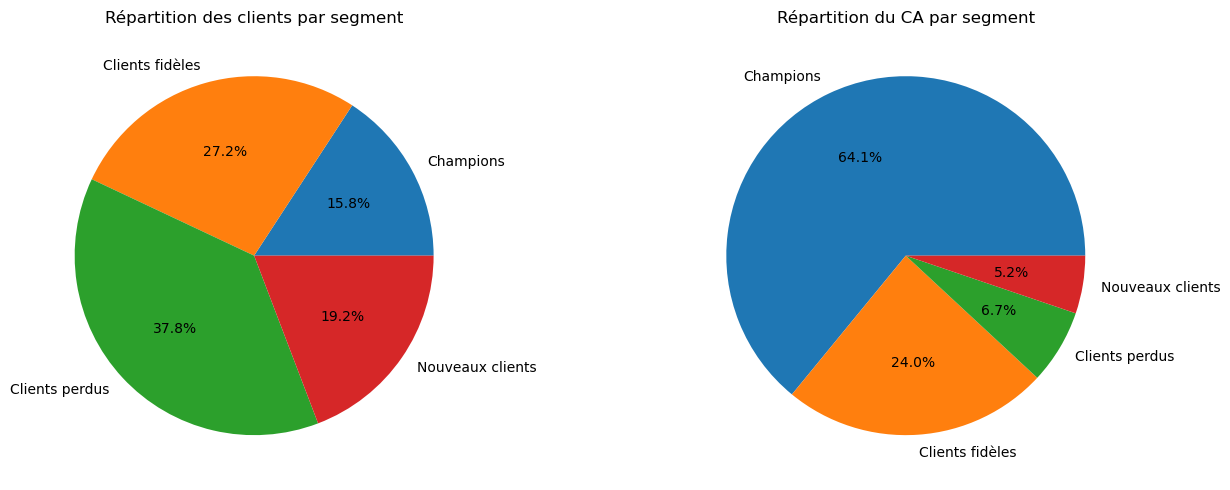

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie % clients vs % CA
axes[0].pie(kpi_segments["Pct_clients"], labels=kpi_segments.index,
            autopct="%1.1f%%", colors=sns.color_palette("tab10"))
axes[0].set_title("Répartition des clients par segment")

axes[1].pie(kpi_segments["Pct_CA"], labels=kpi_segments.index,
            autopct="%1.1f%%", colors=sns.color_palette("tab10"))
axes[1].set_title("Répartition du CA par segment")

plt.tight_layout()
plt.show()

### 9.4 KPI géographiques

In [51]:
kpi_pays = (df_clean.groupby("Country")
            .agg(CA=("TotalPrice", "sum"),
                 Commandes=("InvoiceNo", "nunique"),
                 Clients=("CustomerID", "nunique"))
            .sort_values("CA", ascending=False))
kpi_pays["Panier_moyen"] = (kpi_pays["CA"] / kpi_pays["Commandes"]).round(2)
kpi_pays["CA_par_client"] = (kpi_pays["CA"] / kpi_pays["Clients"]).round(2)
kpi_pays["Pct_CA"] = (kpi_pays["CA"] / kpi_pays["CA"].sum() * 100).round(2)

print("Top 10 pays par CA :")
kpi_pays.head(10).round(1)

Top 10 pays par CA :


,CA,Commandes,Clients,Panier_moyen,CA_par_client,Pct_CA
Country,,,,,,
United Kingdom,6997202.1,16577,3915,422.1,1787.3,82.4
Netherlands,283889.3,93,9,3052.6,31543.3,3.3
EIRE,257013.1,256,3,1004.0,85671.0,3.0
Germany,205381.2,443,94,463.6,2184.9,2.4
France,183801.9,379,87,485.0,2112.7,2.2
Australia,138103.8,56,9,2466.1,15344.9,1.6
Spain,55706.6,88,30,633.0,1856.9,0.7
Switzerland,52442.0,47,21,1115.8,2497.2,0.6
Japan,37416.4,19,8,1969.3,4677.0,0.4


In [52]:
kpi_pays.drop("United Kingdom").head(10).round(1)

,CA,Commandes,Clients,Panier_moyen,CA_par_client,Pct_CA
Country,,,,,,
Netherlands,283889.3,93,9,3052.6,31543.3,3.3
EIRE,257013.1,256,3,1004.0,85671.0,3.0
Germany,205381.2,443,94,463.6,2184.9,2.4
France,183801.9,379,87,485.0,2112.7,2.2
Australia,138103.8,56,9,2466.1,15344.9,1.6
Spain,55706.6,88,30,633.0,1856.9,0.7
Switzerland,52442.0,47,21,1115.8,2497.2,0.6
Japan,37416.4,19,8,1969.3,4677.0,0.4
Belgium,36927.3,98,25,376.8,1477.1,0.4


### 9.5 KPI saisonnalité

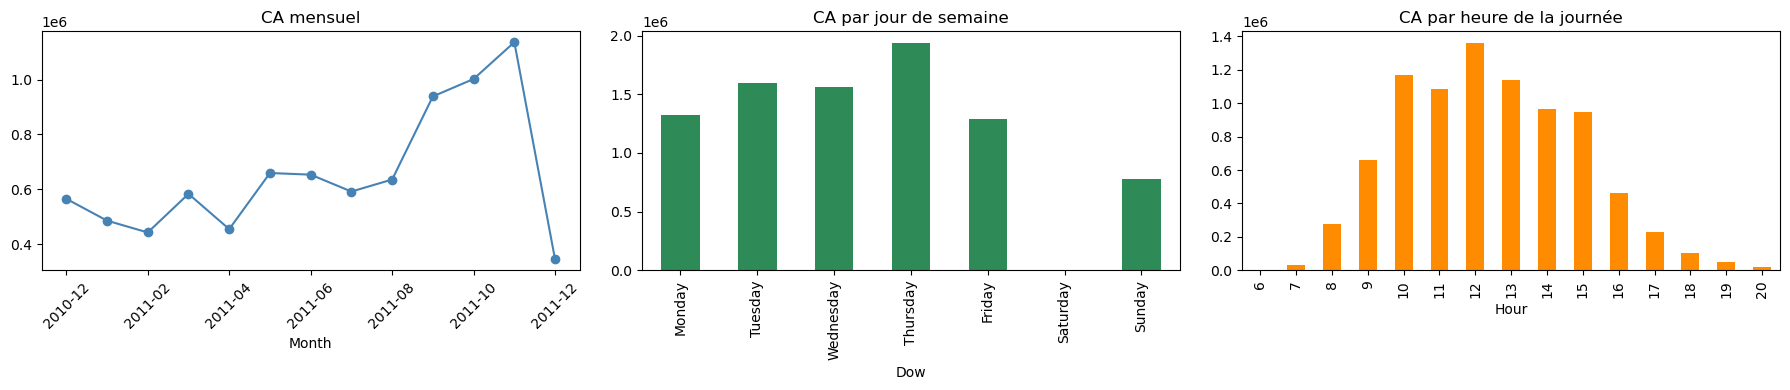

Croissance mensuelle (%) :


Month
2010-12     NaN
2011-01   -14.1
2011-02    -8.9
2011-03    31.8
2011-04   -22.1
2011-05    45.1
2011-06    -0.9
2011-07    -9.4
2011-08     7.4
2011-09    47.7
2011-10     6.8
2011-11    13.4
Name: TotalPrice, dtype: float64

In [53]:
df_clean["Year"]  = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)
df_clean["Dow"]   = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hour"]  = df_clean["InvoiceDate"].dt.hour

# CA mensuel
ca_mensuel = df_clean.groupby("Month")["TotalPrice"].sum()
croissance_mensuelle = ca_mensuel.pct_change().mul(100).round(1)

# CA par jour de semaine
ca_dow = df_clean.groupby("Dow")["TotalPrice"].sum().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

# CA par heure
ca_heure = df_clean.groupby("Hour")["TotalPrice"].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ca_mensuel.plot(ax=axes[0], marker="o", color="steelblue")
axes[0].set_title("CA mensuel")
axes[0].tick_params(axis="x", rotation=45)

ca_dow.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("CA par jour de semaine")

ca_heure.plot(kind="bar", ax=axes[2], color="darkorange")
axes[2].set_title("CA par heure de la journée")

plt.tight_layout()
plt.show()

print("Croissance mensuelle (%) :")
croissance_mensuelle.head(12)

### 9.6 KPI Produits (top/flop)

In [54]:
kpi_produits = (df_clean.groupby(["StockCode", "Description"])
                .agg(CA=("TotalPrice", "sum"),
                     Qte=("Quantity", "sum"),
                     Nb_commandes=("InvoiceNo", "nunique"),
                     Nb_clients=("CustomerID", "nunique"))
                .sort_values("CA", ascending=False))

print("Top 10 produits par CA :")
display(kpi_produits.head(10).round(0))

print("\nTop 10 produits par quantité vendue :")
display(kpi_produits.sort_values("Qte", ascending=False).head(10).round(0))

print("\nBottom 10 produits (CA le plus faible, > 0) :")
display(kpi_produits[kpi_produits["CA"] > 0].tail(10).round(0))

Top 10 produits par CA :


,,CA,Qte,Nb_commandes,Nb_clients
StockCode,Description,,,,
22423,REGENCY CAKESTAND 3 TIER,142265.0,12374,1703,881
85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.0,36706,1971,856
85099B,JUMBO BAG RED RETROSPOT,85041.0,46078,1600,635
47566,PARTY BUNTING,68785.0,15279,1379,708
84879,ASSORTED COLOUR BIRD ORNAMENT,56413.0,35263,1375,678
23084,RABBIT NIGHT LIGHT,51251.0,27153,801,450
79321,CHILLI LIGHTS,46265.0,9646,519,205
22086,PAPER CHAIN KIT 50'S CHRISTMAS,42584.0,15591,980,613
22502,PICNIC BASKET WICKER 60 PIECES,39620.0,61,2,1



Top 10 produits par quantité vendue :


,,CA,Qte,Nb_commandes,Nb_clients
StockCode,Description,,,,
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,13558.0,54319,472,307
85099B,JUMBO BAG RED RETROSPOT,85041.0,46078,1600,635
85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.0,36706,1971,856
84879,ASSORTED COLOUR BIRD ORNAMENT,56413.0,35263,1375,678
21212,PACK OF 72 RETROSPOT CAKE CASES,16382.0,33670,1029,635
22197,POPCORN HOLDER,23418.0,30919,632,295
23084,RABBIT NIGHT LIGHT,51251.0,27153,801,450
22492,MINI PAINT SET VINTAGE,16039.0,26076,325,213
22616,PACK OF 12 LONDON TISSUES,7262.0,25329,382,195



Bottom 10 produits (CA le plus faible, > 0) :


,,CA,Qte,Nb_commandes,Nb_clients
StockCode,Description,,,,
84743C,ORANGE FELT VASE + FLOWERS,1.0,1,1,1
90128B,BLUE LEAVES AND BEADS PHONE CHARM,1.0,1,1,1
84990,60 GOLD AND SILVER FAIRY CAKE CASES,1.0,2,2,2
84206B,CAT WITH SUNGLASSES BLANK CARD,1.0,5,1,1
84201C,HAPPY BIRTHDAY CARD TEDDY/CAKE,1.0,5,1,1
90084,PINK CRYSTAL GUITAR PHONE CHARM,1.0,1,1,1
90104,PURPLE FRANGIPANI HAIRCLIP,1.0,1,1,1
21268,VINTAGE BLUE TINSEL REEL,1.0,2,1,1
23366,SET 12 COLOURING PENCILS DOILEY,1.0,1,1,1


### 9.7 KPI de rétention

In [55]:
# --- Taux de clients mono-commande ---
mono = (rfm["Frequency"] == 1).sum()
pct_mono = mono / len(rfm) * 100

# --- Taux de réachat ---
reacheteurs = (rfm["Frequency"] > 1).sum()
taux_reachat = reacheteurs / len(rfm) * 100

# --- Rétention par segment ---
retention_seg = (rfm.assign(reachat=rfm["Frequency"] > 1)
                 .groupby("Segment")["reachat"]
                 .mean().mul(100).round(1)
                 .sort_values(ascending=False))

# --- Valeur vie client (LTV simplifiée) ---
ltv_moyen = (rfm["Monetary"] / rfm["Frequency"]).mean() * rfm["Frequency"].mean()

print(f"Clients mono-commande : {mono} ({pct_mono:.1f}%)")
print(f"Clients réacheteurs   : {reacheteurs} ({taux_reachat:.1f}%)")
print(f"LTV simplifiée moyenne : £{ltv_moyen:,.0f}\n")
print("Taux de réachat par segment (%):")
print(retention_seg)

Clients mono-commande : 1505 (34.7%)
Clients réacheteurs   : 2828 (65.3%)
LTV simplifiée moyenne : £1,607

Taux de réachat par segment (%):
Segment
Champions           100.0
Clients fidèles      97.5
Nouveaux clients     67.0
Clients perdus       26.7
Name: reachat, dtype: float64


### 9.8 Tableau récapitulatif

In [56]:
dashboard = pd.DataFrame({
    "KPI": [
        "💰 CA total (£)",
        "📦 Commandes totales",
        "👥 Clients uniques",
        "🛒 Panier moyen (£)",
        "💎 CA par client (£)",
        "🔁 Fréquence moyenne",
        "⭐ Segment le plus rentable",
        "⚠️ Segment le plus à risque",
        "📉 % CA des Champions",
        "📈 % CA des Clients perdus",
        "🎯 % clients qui font 80% du CA",
        "🌍 Pays principal (hors UK)",
    ],
    "Valeur": [
        f"{total_revenue:,.0f}",
        f"{total_orders:,}",
        f"{total_clients:,}",
        f"{panier_moyen:,.2f}",
        f"{ca_par_client:,.2f}",
        f"{freq_moyenne:.2f}",
        kpi_segments.index[0],
        "Clients perdus",
        f"{kpi_segments.loc['Champions', 'Pct_CA']:.1f}%",
        f"{kpi_segments.loc['Clients perdus', 'Pct_CA']:.1f}%",
        f"{pct_clients_80:.1f}%",
        kpi_pays.drop("United Kingdom").index[0],
    ]
})
dashboard

,KPI,Valeur
0,💰 CA total (£),"8,491,574"
1,📦 Commandes totales,"18,400"
2,👥 Clients uniques,"4,333"
3,🛒 Panier moyen (£),461.50
4,💎 CA par client (£),"1,959.74"
5,🔁 Fréquence moyenne,4.25
6,⭐ Segment le plus rentable,Champions
7,⚠️ Segment le plus à risque,Clients perdus
8,📉 % CA des Champions,64.0%
9,📈 % CA des Clients perdus,6.7%


In [57]:
# !pip install pyarrow pandas-gbq --quiet

import pandas_gbq


ton_id_projet = "machine-learning-online-retail"   # ← ID de projet Google Cloud
DATASET       = "resultats_ml"                      # ← dataset BigQuery


# 2. FONCTIONS UTILITAIRES

def nettoyer_colonnes(df):
    """Nettoie les noms de colonnes pour BigQuery/Looker Studio."""
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.replace("%", "pct", regex=False)
        .str.replace("£", "GBP", regex=False)
        .str.replace(" ", "_", regex=False)
        .str.replace(r"[^\w]", "", regex=True)
    )
    return df


def envoyer_vers_bigquery(df, nom_table):
    """Envoie un DataFrame vers BigQuery avec gestion d'erreur."""
    df_propre = nettoyer_colonnes(df)
    print(f"⏳ Envoi de '{nom_table}' ({len(df_propre)} lignes)...")
    try:
        pandas_gbq.to_gbq(
            df_propre,
            destination_table=f"{DATASET}.{nom_table}",
            project_id=ton_id_projet,
            if_exists="replace",
            auth_local_webserver=True,
        )
        print(f"   ✅ '{nom_table}' envoyé avec succès !")
    except Exception as e:
        print(f" Erreur sur '{nom_table}' : {e}")


# 3. VÉRIFICATIONS PRÉALABLES

# Vérification que df_clean existe
if "df_clean" not in dir():
    raise NameError("df_clean n'existe pas. Exécute d'abord le nettoyage (section 2).")

# Vérification / recréer TotalPrice
if "TotalPrice" not in df_clean.columns:
    df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]
    print("Colonne 'TotalPrice' recréée")

# Vérification que rfm existe
if "rfm" not in dir():
    raise NameError("❌ rfm n'existe pas. Exécute d'abord la section 3 (matrice RFM).")

# Vérification que Cluster existe
if "Cluster" not in rfm.columns:
    raise NameError("❌ 'Cluster' absent de rfm. Exécute d'abord la section 6 (K-Means).")


# 4. RECONSTRUCTION DES KPI GLOBAUX

total_revenue  = df_clean["TotalPrice"].sum()
total_orders   = df_clean["InvoiceNo"].nunique()
total_clients  = df_clean["CustomerID"].nunique()
total_products = df_clean["StockCode"].nunique()
nb_pays        = df_clean["Country"].nunique()

panier_moyen   = total_revenue / total_orders
ca_par_client  = total_revenue / total_clients
freq_moyenne   = total_orders / total_clients
duree_periode  = (df_clean["InvoiceDate"].max()
                  - df_clean["InvoiceDate"].min()).days
ca_jour_moyen  = total_revenue / duree_periode

df_kpi_globaux_export = pd.DataFrame([{
    "CA_total":            total_revenue,
    "Commandes_totales":   total_orders,
    "Clients_uniques":     total_clients,
    "Produits_distincts":  total_products,
    "Pays":                nb_pays,
    "Panier_moyen":        panier_moyen,
    "CA_par_client":       ca_par_client,
    "Frequence_moyenne":   freq_moyenne,
    "Duree_periode_jours": duree_periode,
    "CA_jour_moyen":       ca_jour_moyen
}])


# 5. RECONSTRUCTION DU KPI PAR CLUSTER

cluster_kpi = rfm.groupby("Cluster").agg(
    Nb_Clients          = ("Monetary", "count"),
    CA_Total            = ("Monetary", "sum"),
    CA_Median           = ("Monetary", "median"),
    Panier_Moyen_Client = ("Monetary", "mean"),
    Recence_Moyenne     = ("Recency", "mean"),
    Frequence_Moyenne   = ("Frequency", "mean"),
    Frequence_Mediane   = ("Frequency", "median"),
)
cluster_kpi["Part_Clients_pct"] = (
    cluster_kpi["Nb_Clients"] / cluster_kpi["Nb_Clients"].sum() * 100
).round(1)
cluster_kpi["Part_CA_pct"] = (
    cluster_kpi["CA_Total"] / cluster_kpi["CA_Total"].sum() * 100
).round(1)
cluster_kpi["CA_par_Client"] = (
    cluster_kpi["CA_Total"] / cluster_kpi["Nb_Clients"]
).round(0)
cluster_kpi = cluster_kpi.sort_values("CA_Total", ascending=False).reset_index()


# 6. RECONSTRUCTION DU KPI PAR SEGMENT (PERSONA)

if "Segment" not in rfm.columns:
    noms_segments = {
        0: "Champions",
        1: "Clients perdus",
        2: "Nouveaux clients",
        3: "Clients fidèles",
    }
    rfm["Segment"] = rfm["Cluster"].map(noms_segments)

kpi_segments = rfm.groupby("Segment").agg(
    Nb_Clients          = ("Monetary", "count"),
    CA_Total            = ("Monetary", "sum"),
    CA_Median           = ("Monetary", "median"),
    Panier_Moyen_Client = ("Monetary", "mean"),
    Recence_Moyenne     = ("Recency", "mean"),
    Frequence_Moyenne   = ("Frequency", "mean"),
)
kpi_segments["Part_Clients_pct"] = (
    kpi_segments["Nb_Clients"] / kpi_segments["Nb_Clients"].sum() * 100
).round(1)
kpi_segments["Part_CA_pct"] = (
    kpi_segments["CA_Total"] / kpi_segments["CA_Total"].sum() * 100
).round(1)
kpi_segments["CA_par_Client"] = (
    kpi_segments["CA_Total"] / kpi_segments["Nb_Clients"]
).round(0)
kpi_segments = kpi_segments.sort_values("CA_Total", ascending=False).reset_index()


# 7. RECONSTRUCTION DU KPI PAR PAYS

kpi_pays = (df_clean.groupby("Country")
            .agg(CA=("TotalPrice", "sum"),
                 Commandes=("InvoiceNo", "nunique"),
                 Clients=("CustomerID", "nunique"))
            .sort_values("CA", ascending=False))
kpi_pays["Panier_moyen"]  = (kpi_pays["CA"] / kpi_pays["Commandes"]).round(2)
kpi_pays["CA_par_client"] = (kpi_pays["CA"] / kpi_pays["Clients"]).round(2)
kpi_pays["Part_CA_pct"]   = (kpi_pays["CA"] / kpi_pays["CA"].sum() * 100).round(2)
kpi_pays = kpi_pays.reset_index()


# 8. RECONSTRUCTION DU KPI TEMPOREL

df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)
ca_mensuel = df_clean.groupby("Month")["TotalPrice"].sum().reset_index()
ca_mensuel.columns = ["Month", "CA"]


# 9. RECONSTRUCTION DU KPI PRODUITS

kpi_produits = (df_clean.groupby(["StockCode", "Description"])
                .agg(CA=("TotalPrice", "sum"),
                     Qte=("Quantity", "sum"),
                     Nb_commandes=("InvoiceNo", "nunique"),
                     Nb_clients=("CustomerID", "nunique"))
                .sort_values("CA", ascending=False)
                .reset_index()
                .head(100))


# 10. ENVOI DE TOUS LES KPI VERS BIGQUERY

envoyer_vers_bigquery(df_kpi_globaux_export, "kpi_globaux")
envoyer_vers_bigquery(kpi_segments,          "kpi_segments")
envoyer_vers_bigquery(cluster_kpi,           "kpi_clusters")
envoyer_vers_bigquery(kpi_pays,              "kpi_pays")
envoyer_vers_bigquery(ca_mensuel,            "kpi_temporel")
envoyer_vers_bigquery(kpi_produits,          "kpi_produits")

print("\n Tous les KPI sont dans BigQuery, prêts pour Looker Studio.")

⏳ Envoi de 'kpi_globaux' (1 lignes)...
 Erreur sur 'kpi_globaux' : 403 GET https://bigquery.googleapis.com/bigquery/v2/projects/machine-learning-online-retail/datasets/resultats_ml/tables/kpi_globaux?prettyPrint=false: Access Denied: Table machine-learning-online-retail:resultats_ml.kpi_globaux: Permission bigquery.tables.get denied on table machine-learning-online-retail:resultats_ml.kpi_globaux (or it may not exist).
⏳ Envoi de 'kpi_segments' (4 lignes)...
 Erreur sur 'kpi_segments' : 403 GET https://bigquery.googleapis.com/bigquery/v2/projects/machine-learning-online-retail/datasets/resultats_ml/tables/kpi_segments?prettyPrint=false: Access Denied: Table machine-learning-online-retail:resultats_ml.kpi_segments: Permission bigquery.tables.get denied on table machine-learning-online-retail:resultats_ml.kpi_segments (or it may not exist).
⏳ Envoi de 'kpi_clusters' (4 lignes)...
 Erreur sur 'kpi_clusters' : 403 GET https://bigquery.googleapis.com/bigquery/v2/projects/machine-learning-on

## 10. Sauvegarde du modèle et des données
On enregistre le scaler, le modèle K-means, la PCA et la table RFM finale : le dashboard Streamlit les rechargera pour classer un nouveau client sans tout recalculer.

In [58]:
import os
import joblib

# Création du dossier de sauvegarde
os.makedirs("models", exist_ok=True)

# Modèles entraînés
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(kmeans, "models/kmeans.pkl")
joblib.dump(pca, "models/pca.pkl")

# Dictionnaires des segments et des actions marketing
joblib.dump(noms_segments, "models/noms_segments.pkl")
joblib.dump(actions_marketing, "models/actions_marketing.pkl")

# Table RFM finale (avec Cluster, Segment, Action, PCA1, PCA2)
rfm.to_csv("models/rfm_segments.csv")

print("Fichiers sauvegardés :", os.listdir("models"))

Fichiers sauvegardés : ['actions_marketing.pkl', 'kmeans.pkl', 'noms_segments.pkl', 'pca.pkl', 'rfm_segments.csv', 'scaler.pkl']


## 11. Conclusion

### Synthèse de la démarche
- **Nettoyage** : 541 909 transactions brutes → **391 148 transactions exploitables** pour **4 333 clients** (suppression des clients inconnus, doublons, annulations, prix/quantités ≤ 0, frais non-produits et commandes aberrantes).
- **Matrice RFM** : chaque client est résumé par sa Récence, sa Fréquence et son Montant.
- **Prétraitement** : transformation **log1p** pour corriger la forte asymétrie (skew du Montant : 20,9 → 0,36), puis **standardisation**.
- **Choix de K = 4** : coude de l'inertie autour de 4, silhouette identique pour K = 3 et K = 4 (0,338), et 4 segments plus actionnables pour le marketing.
- **Modèle retenu : K-means**, meilleure silhouette que le hiérarchique (0,338 vs 0,264) et capable de classer de nouveaux clients.
- **PCA** : les 2 premières composantes expliquent **94 % de la variance** et confirment la bonne séparation des segments.

### Résultats clés
| Segment | % clients | % CA |
|---|---|---|
| 🏆 Champions | 16 % | **64 %** |
| 💙 Clients fidèles | 27 % | 24 % |
| 🌱 Nouveaux clients | 19 % | 5 % |
| 💤 Clients perdus | **38 %** | 7 % |

→ Le chiffre d'affaires est **très concentré** : 16 % des clients génèrent près des deux tiers du CA, tandis que plus d'un tiers des clients sont inactifs.

### Recommandations stratégiques
1. **Sécuriser les Champions** : programme VIP et attention personnalisée ; leur perte serait critique.
2. **Faire progresser les Clients fidèles** vers le statut de Champions (fidélité à paliers, ventes croisées).
3. **Convertir les Nouveaux clients** dès la 2e commande (bienvenue, code promo).
4. **Réactiver les Clients perdus** avec des campagnes à faible coût, et mesurer le retour avant d'investir davantage.
5. **Suivre l'évolution des segments** chaque mois pour détecter tôt les clients qui décrochent.

### Limites de l'approche
- **25 % des transactions** n'avaient pas de CustomerID et ont été exclues : une partie de la clientèle n'est pas analysée.
- **Une seule année** de données (déc. 2010 → déc. 2011), avec un mois de décembre 2011 incomplet.
- Activité concentrée à **82 % sur le Royaume-Uni** : les segments reflètent surtout la clientèle britannique.
- La RFM ne tient compte ni des **marges**, ni des **catégories de produits**, ni du **canal d'acquisition**.
- La silhouette (0,338) est **modérée** : les comportements d'achat sont continus et les frontières entre segments ne sont pas nettes.
- Les segments sont une **photo à une date donnée** : ils doivent être recalculés régulièrement.

### Perspectives
- Mettre à jour la segmentation **mensuellement** à partir des nouvelles transactions.
- Enrichir l'analyse avec d'autres variables (pays, catégories de produits, marge).
- Mesurer l'efficacité des actions marketing par segment (A/B tests).
- Tester d'autres algorithmes (DBSCAN, modèles de mélange gaussien).